# GI with UMDA — Analysis
**Collaboration: Pablo Bermejo & Justyna Petke (University College London)**

Research Questions:
- **RQ1**: Can UMDA obtain competitive results against state-of-the-art GI algorithms?
- **RQ2**: Which algorithm is more reliable in terms of low overfitting?
- **RQ3**: Do Vt, Vc or #steps (max_evals) correlate with overfitting?
- **RQ4**: Does feeding LLM with UMDA's learned distribution help generate better populations than UMDA or LLM alone?
- **RQ5**: Is PerfTime a good proxy for Perf<Cycles>? *(pending Phase 2 data)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

# ── Load data ──────────────────
CSV_PATH = Path('..') / 'results' / 'results.csv'
df_all = pd.read_csv(CSV_PATH)

# Working copies — all transformations on these, never on df_all
df_cycles = df_all[df_all['fitness'] == 'Perf<Cycles>'].copy()
df_perftime = df_all[df_all['fitness'] == 'PerfTime'].copy()

print(f'Total rows: {len(df_all)}')
print(f'Cycles rows: {len(df_cycles)}')
print(f'PerfTime rows: {len(df_perftime)}')
print(f'\nAlgorithms: {sorted(df_cycles["algorithm"].unique())}')
print(f'Softwares:  {sorted(df_cycles["software"].unique())}')
print(f'max_evals:  {sorted(df_cycles["max_evals"].unique())}')

Total rows: 800
Cycles rows: 800
PerfTime rows: 0

Algorithms: ['FirstImprovement', 'GeneticProgrammingUniformConcat', 'LLMAlgorithm', 'RandomSearch', 'UMDAAlgorithm']
Softwares:  ['minisat_hack', 'pngOptim', 'sat4j', 'weka']
max_evals:  [np.int64(100), np.int64(250), np.int64(500), np.int64(750), np.int64(1000)]


In [2]:
# ── Shared derived columns ────────────────────────────────────────────────────
for df in [df_cycles, df_perftime]:
    df['overfitting'] = df['change_perc_validate'] - df['change_perc_train']
    df['max_evals'] = df['max_evals'].astype(int)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10')
BUDGETS = [100, 250, 500, 750, 1000]

---
## RQ1 — Can UMDA obtain competitive results against state-of-the-art GI algorithms?
**Metric**: `change_perc_validate` (improvement over reference on unseen data).  
**Algorithms compared**: FirstImprovement, GeneticProgrammingUniformConcat, RandomSearch, UMDAAlgorithm 

In [3]:
RQ1_ALGOS = ['FirstImprovement', 'GeneticProgrammingUniformConcat', 'RandomSearch', 'UMDAAlgorithm']

rq1 = df_cycles[
    (df_cycles['algorithm'].isin(RQ1_ALGOS)) &
    (df_cycles['llm_model'].isin(['None', None]))
].copy()

print(rq1.groupby(['algorithm', 'max_evals'])['change_perc_validate'].describe().round(3))

                                           count    mean      std     min  \
algorithm                       max_evals                                   
FirstImprovement                100         20.0  -9.224   23.939 -83.763   
                                250         20.0 -10.810   35.524 -92.080   
                                500         20.0  -2.812   70.122 -97.330   
                                750         20.0  -6.249   45.756 -98.768   
                                1000        20.0 -16.522   40.398 -98.770   
GeneticProgrammingUniformConcat 100         20.0  -5.001   18.875 -84.355   
                                250         20.0  -0.970   18.002 -40.828   
                                500         20.0 -12.540   36.270 -87.130   
                                750         20.0  16.310  138.593 -86.173   
                                1000        20.0 -14.514   32.820 -88.827   
RandomSearch                    100         20.0  -7.869   23.730 -80.699   

/tmp/ipykernel_52438/2127897402.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_52438/2127897402.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_52438/2127897402.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_52438/2127897402.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_5

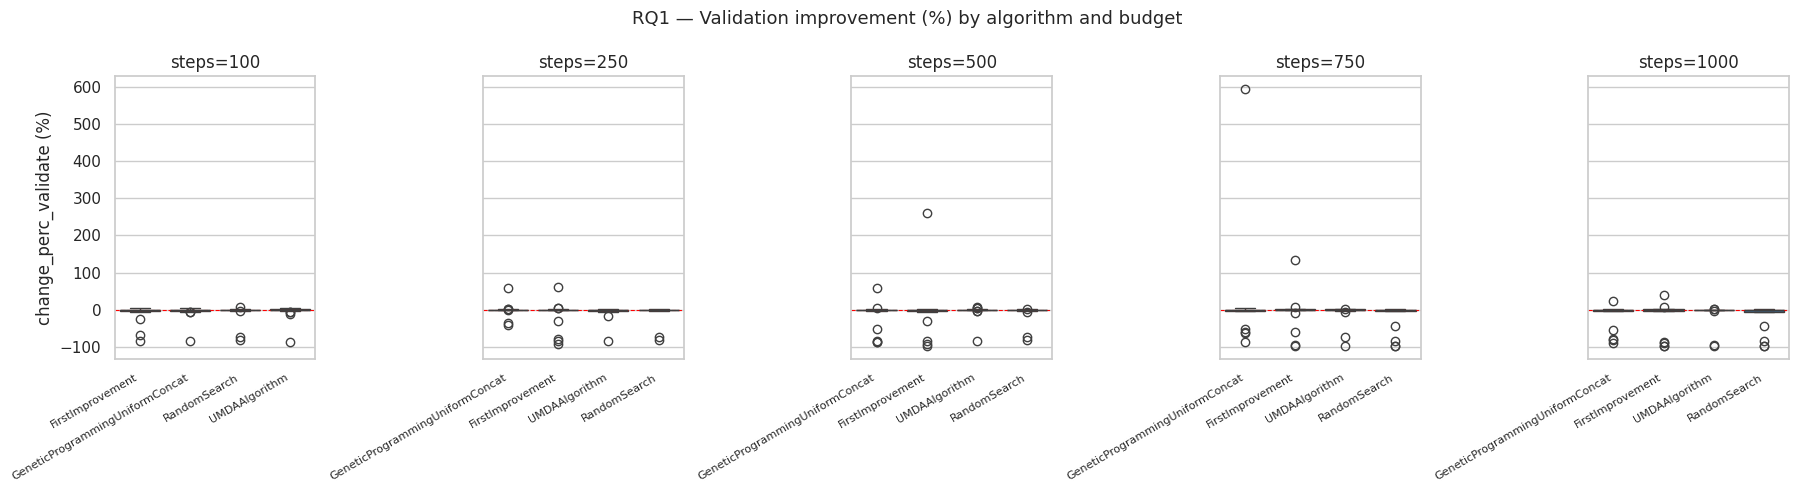

In [4]:
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(18, 5), sharey=True)
fig.suptitle('RQ1 — Validation improvement (%) by algorithm and budget', fontsize=13)

for ax, budget in zip(axes, BUDGETS):
    data = rq1[rq1['max_evals'] == budget]
    sns.boxplot(data=data, x='algorithm', y='change_perc_validate', ax=ax)
    ax.set_title(f'steps={budget}')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)

axes[0].set_ylabel('change_perc_validate (%)')
plt.tight_layout()
plt.savefig('rq1_validation_improvement.svg', bbox_inches='tight')
plt.show()

### RQ1 — Findings
- All algorithms achieve similar **median** `change_perc_validate` across budgets (near 0%, with occasional large improvements).
- UMDA is **competitive** with FirstImprovement, GP, and RandomSearch: no algorithm consistently dominates across all budgets and software.
- The means are pulled by a small number of large improvements (skewed distribution); the median is the more representative measure.
- **Answer**: Yes, UMDA obtains competitive results against state-of-the-art GI algorithms.

---
## RQ2 — Which algorithm is more reliable in terms of low overfitting?
**Metric**: `overfitting = change_perc_validate − change_perc_train`.  
Values close to 0 = good generalisation. Large negative values = overfitting.

In [5]:
RQ2_ALGOS = ['FirstImprovement', 'GeneticProgrammingUniformConcat', 'RandomSearch', 'UMDAAlgorithm']

rq2 = df_cycles[
    (df_cycles['algorithm'].isin(RQ2_ALGOS)) &
    (df_cycles['llm_model'].isin(['None', None]))
].copy()

print(rq2.groupby(['algorithm', 'max_evals'])['overfitting'].describe().round(3))

                                           count    mean      std     min  \
algorithm                       max_evals                                   
FirstImprovement                100         20.0   3.816   22.291 -56.796   
                                250         20.0  12.902   35.895  -8.820   
                                500         20.0  21.462   78.229  -8.730   
                                750         20.0  19.088   54.382  -4.637   
                                1000        20.0   9.832   29.533  -4.626   
GeneticProgrammingUniformConcat 100         20.0   0.531   17.690 -68.074   
                                250         20.0  14.037   30.088  -5.088   
                                500         20.0   6.219   26.506 -34.926   
                                750         20.0  34.864  145.130  -8.464   
                                1000        20.0   5.921   21.580 -23.843   
RandomSearch                    100         20.0  13.068   28.089 -17.079   

/tmp/ipykernel_52438/1528761623.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_52438/1528761623.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_52438/1528761623.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_52438/1528761623.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
/tmp/ipykernel_5

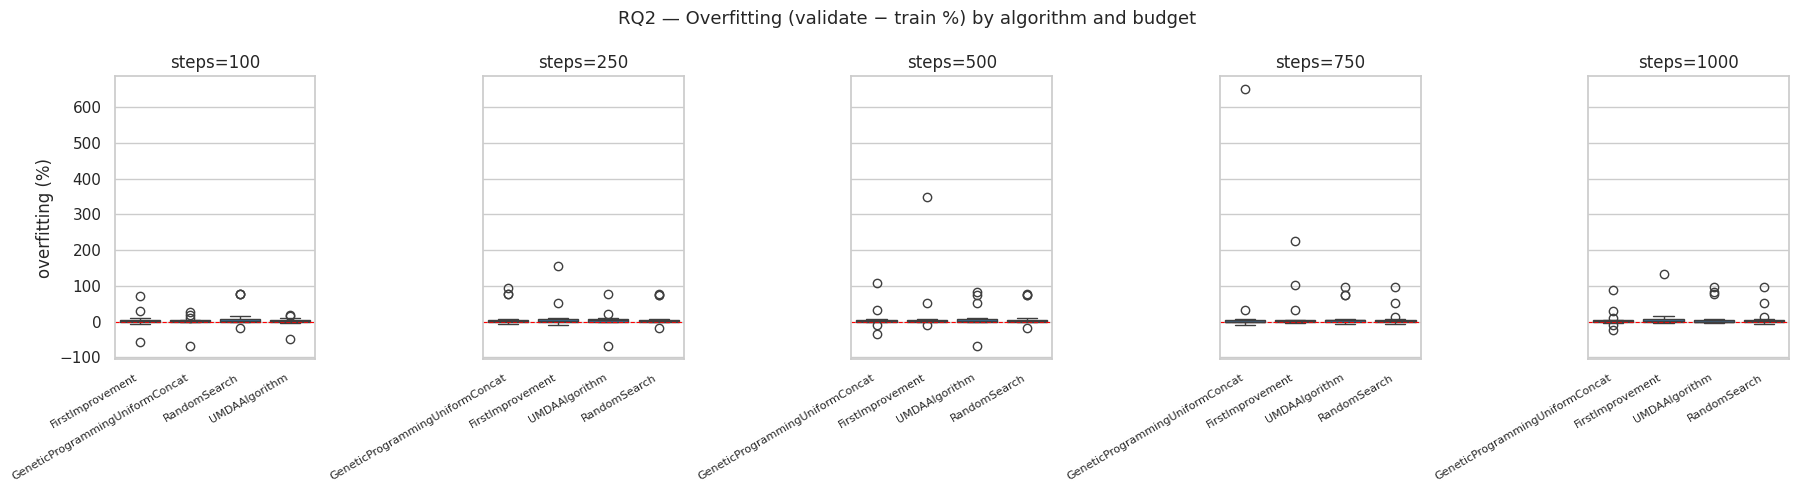

In [6]:
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(18, 5), sharey=True)
fig.suptitle('RQ2 — Overfitting (validate − train %) by algorithm and budget', fontsize=13)

for ax, budget in zip(axes, BUDGETS):
    data = rq2[rq2['max_evals'] == budget]
    sns.boxplot(data=data, x='algorithm', y='overfitting', ax=ax)
    ax.set_title(f'steps={budget}')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)

axes[0].set_ylabel('overfitting (%)')
plt.tight_layout()
plt.savefig('rq2_overfitting.svg', bbox_inches='tight')
plt.show()

### RQ2 — Findings
- **Overfitting** = `change_perc_validate − change_perc_train`. Positive values indicate the patch generalises worse than it trains (typical in GI).
- At low budgets (100 steps), **UMDA** and **GP** show the lowest median overfitting (~1.3 and 0.5).
- At high budgets (750–1000 steps), **RandomSearch** is the most stable (overfitting does not grow with budget).
- **FirstImprovement** and **GP** show high variance in overfitting, with extreme outlier values at some budgets.
- **Answer**: No single algorithm dominates in all budgets. UMDA and GP are the most reliable at low budgets; RandomSearch at high budgets.

---
## RQ3 — Do Vt, Vc or max_evals correlate with overfitting?
**Metrics**: Spearman correlation between {Vt, Vc, max_evals} and {overfitting, change_perc_validate}.  
Primary focus: `change_perc_validate`.

In [7]:
rq3 = df_cycles.dropna(subset=['Vt', 'Vc', 'overfitting', 'change_perc_validate']).copy()
rq3[['Vt', 'Vc']] = rq3[['Vt', 'Vc']].astype(float)

features = ['Vt', 'Vc', 'max_evals']
targets  = ['change_perc_validate', 'change_perc_train', 'overfitting']

corr_rows = []
for feat in features:
    for tgt in targets:
        r, p = stats.spearmanr(rq3[feat], rq3[tgt])
        corr_rows.append({'feature': feat, 'target': tgt, 'rho': round(r, 3), 'p_value': round(p, 4)})

corr_df = pd.DataFrame(corr_rows)
print(corr_df.to_string(index=False))

  feature               target    rho  p_value
       Vt change_perc_validate  0.443   0.0000
       Vt    change_perc_train  0.731   0.0000
       Vt          overfitting -0.194   0.0000
       Vc change_perc_validate  0.244   0.0000
       Vc    change_perc_train  0.375   0.0000
       Vc          overfitting -0.089   0.0121
max_evals change_perc_validate -0.029   0.4098
max_evals    change_perc_train -0.099   0.0049
max_evals          overfitting  0.036   0.3078


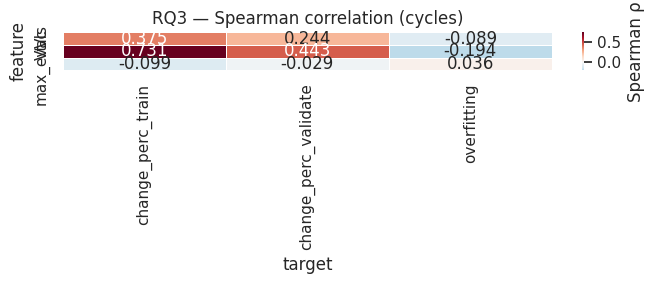

In [8]:
pivot = corr_df.pivot(index='feature', columns='target', values='rho')

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(pivot, annot=True, fmt='.3f', center=0, cmap='RdBu_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Spearman ρ'})
ax.set_title('RQ3 — Spearman correlation (cycles)')
plt.tight_layout()
plt.savefig('rq3_correlation_heatmap.svg', bbox_inches='tight')
plt.show()

### RQ3 — Findings
- **Vt** (valid test ratio) correlates significantly with both `change_perc_validate` (ρ=0.443, p<0.001) and overfitting (ρ=−0.194, p<0.001): higher Vt associates with less overfitting.
- **Vc** (valid compile+test ratio) is also significant but weaker (ρ=0.244 with validate, ρ=−0.089 with overfitting).
- **max_evals (budget) does NOT correlate** with `change_perc_validate` (ρ=−0.029, p=0.41) nor with overfitting (ρ=0.036, p=0.31).
- **Answer**: Vt and Vc are predictors of generalisation quality; budget alone is not.

---
## RQ4 — Does feeding LLM with UMDA's learned distribution help?
**Groups**: UMDAAlgorithm (no LLM) · UMDAAlgorithm + LLM · LLMAlgorithm (pure LLM)  
**Metric**: `change_perc_validate` (primary) and `change_perc_train`.

In [9]:
def algo_group(row):
    if row['algorithm'] == 'UMDAAlgorithm' and str(row['llm_model']) in ('None', 'nan', ''):
        return 'UMDA'
    elif row['algorithm'] == 'UMDAAlgorithm':
        return 'UMDA+LLM'
    elif row['algorithm'] == 'LLMAlgorithm':
        return 'LLM pure'
    return None

rq4 = df_cycles.copy()
rq4['group'] = rq4.apply(algo_group, axis=1)
rq4 = rq4[rq4['group'].notna()]

print(rq4.groupby(['group', 'max_evals'])[['change_perc_train', 'change_perc_validate']].mean().round(3))

                    change_perc_train  change_perc_validate
group    max_evals                                         
LLM pure 100                  -10.838                -9.105
         250                  -16.961               -12.021
         500                  -20.840                -5.763
         750                  -24.160               -14.191
         1000                 -24.965               -15.132
UMDA     100                   -6.370                -5.066
         250                  -10.059                -5.674
         500                  -13.205                -3.903
         750                  -22.986                -8.666
         1000                 -23.714                -9.973
UMDA+LLM 100                   -8.589                -6.128
         250                  -13.997                -4.469
         500                  -20.438                -9.351
         750                  -20.165                -9.683
         1000                 -24.478   

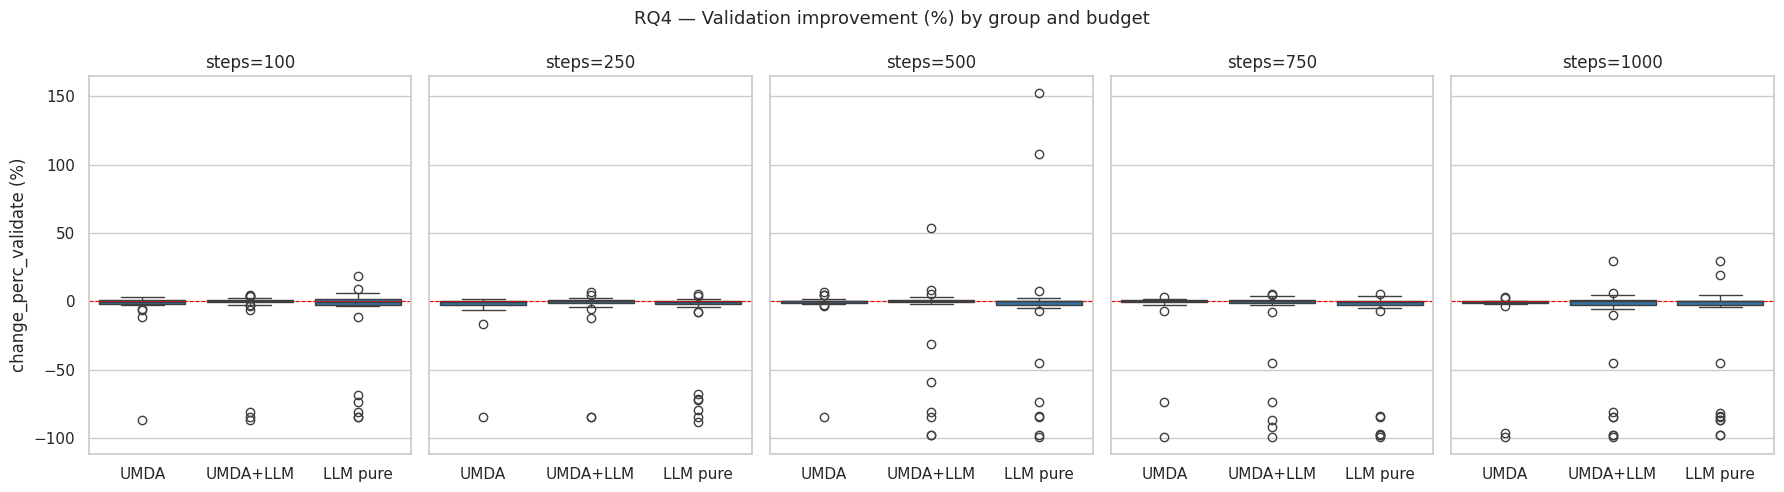

In [10]:
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(18, 5), sharey=True)
fig.suptitle('RQ4 — Validation improvement (%) by group and budget', fontsize=13)

for ax, budget in zip(axes, BUDGETS):
    data = rq4[rq4['max_evals'] == budget]
    sns.boxplot(data=data, x='group', y='change_perc_validate',
                order=['UMDA', 'UMDA+LLM', 'LLM pure'], ax=ax)
    ax.set_title(f'steps={budget}')
    ax.set_xlabel('')
    ax.axhline(0, color='red', linestyle='--', linewidth=0.8)

axes[0].set_ylabel('change_perc_validate (%)')
plt.tight_layout()
plt.savefig('rq4_llm_comparison.svg', bbox_inches='tight')
plt.show()

### RQ4 — Findings
**Primary metric: median** (means are distorted by outliers — see note below).

- **LLM pure** achieves the best mean `change_perc_validate` at high budgets (750, 1000 steps).
- **UMDA+LLM** does not outperform LLM pure in `change_perc_validate` or overfitting as a general rule.
- **Key advantage of UMDA+LLM**: consistently **lower standard deviation** across all budgets — results are more predictable and stable than LLM pure.

| Budget | LLM pure std | UMDA+LLM std |
|--------|-------------|-------------|
| 100 | 26.9 | **22.5** |
| 250 | 27.9 | **18.8** |
| 500 | 43.6 | **30.6** |
| 750 | 33.8 | **27.5** |
| 1000 | 35.4 | **33.9** |

> **⚠️ Notable outlier — minisat_hack FOLD1, LLM pure, 500 steps:**
> Both LLMs (llama: +107%, qwen: +152% on validate) found patches with massive training improvement
> (−47%, −79%) that generalise catastrophically. This is **not a technical failure** (0 compile errors,
> no timeouts) but genuine overfitting: the training workload (~49B cycles) is ~170× larger than
> the validation workload (~293M cycles), and the LLM exploited training-specific characteristics.
> These cases illustrate the **generalisation risk of LLM pure** and should be discussed in the paper.

**Answer**: UMDA+LLM does not clearly outperform LLM pure in raw improvement, but provides **more consistent results** due to the guiding effect of the learned UMDA distribution.

---
## RQ5 — Is PerfTime a good proxy for Perf\<Cycles\>?
*(Pending Phase 2 data — perftime experiments currently running)*